In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import poisson

from ita import add_derived, load_raw

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:,.2f}'.format)

CONFIG = {
    'min_hours': 10_000,
    'min_hours_per_employee': 250,
    'max_hours_per_employee': 8_760,
    'min_cohort': 30,
    'include_government': True,
    'drop_cases_gt_employees': True,
    'drop_invalid_naics_year': True,
}

In [ ]:
raw, malformed = load_raw(2025)
df = add_derived(raw)
print(f'Loaded {len(df):,} rows ({len(malformed)} malformed rows excluded, see D-001)')

computable = df[(df['total_hours_worked'] > 0) & (df['annual_average_employees'] > 0)].copy()
print(f'Rows with hours > 0 and employees > 0: {len(computable):,}')

Loaded 383,277 rows (6 malformed rows excluded, see D-001)
Rows with hours > 0 and employees > 0: 378,649


## 1. Minimum hours worked D-003


In [3]:
one_case = pd.DataFrame({'hours_worked': [2_000, 5_000, 10_000, 20_000, 40_000, 100_000, 200_000]})
one_case['approx_full_time_employees'] = one_case['hours_worked'] / 2_000
one_case['TRIR_from_one_case'] = 200_000 / one_case['hours_worked']
one_case

,hours_worked,approx_full_time_employees,TRIR_from_one_case
0,2000,1.00,100.00
1,5000,2.50,40.00
2,10000,5.00,20.00
3,20000,10.00,10.00
4,40000,20.00,5.00
5,100000,50.00,2.00
6,200000,100.00,1.00


### 1.2 Funnel plot

Pooled TRIR, plausible hours only: 3.47
Pooled TRIR, all rows:             0.42  <- distorted by impossible hours


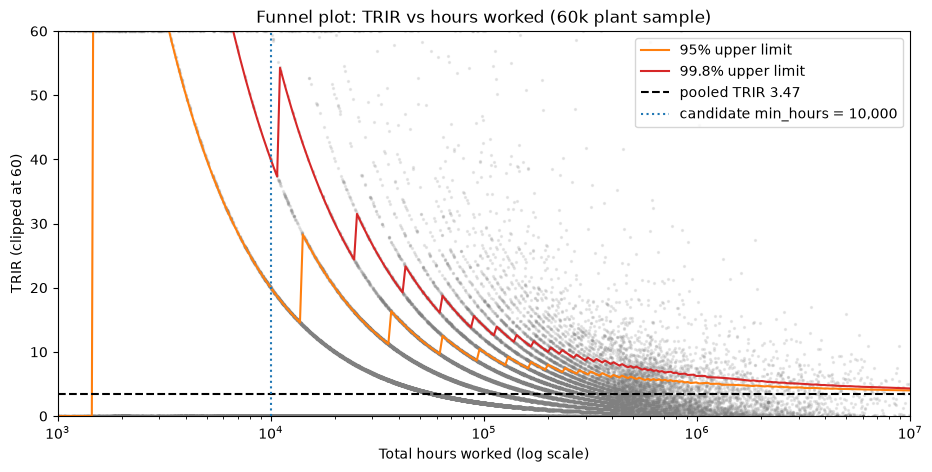

In [ ]:
# Some plants report impossible hours (billions) REMEMBER THIS
plausible = computable['hours_per_employee'].between(CONFIG['min_hours_per_employee'], CONFIG['max_hours_per_employee'])
pooled_rate = computable.loc[plausible, 'recordable_cases'].sum() * 200_000 / computable.loc[plausible, 'total_hours_worked'].sum()
naive_rate = computable['recordable_cases'].sum() * 200_000 / computable['total_hours_worked'].sum()
print(f'Pooled TRIR, plausible hours only: {pooled_rate:.2f}')
print(f'Pooled TRIR, all rows:             {naive_rate:.2f}  <- distorted by impossible hours')

hours_grid = np.logspace(3, 7, 300)
expected_cases = pooled_rate * hours_grid / 200_000

sample = computable.sample(60_000, random_state=0)

fig, ax = plt.subplots(figsize=(11, 5))
ax.scatter(sample['total_hours_worked'], sample['trir'].clip(upper=60), s=2, alpha=0.15, color='grey')
ax.plot(hours_grid, poisson.ppf(0.975, expected_cases) * 200_000 / hours_grid, color='tab:orange', label='95% upper limit')
ax.plot(hours_grid, poisson.ppf(0.999, expected_cases) * 200_000 / hours_grid, color='tab:red', label='99.8% upper limit')
ax.axhline(pooled_rate, color='black', linestyle='--', label=f'pooled TRIR {pooled_rate:.2f}')
ax.axvline(CONFIG['min_hours'], color='tab:blue', linestyle=':', label=f"candidate min_hours = {CONFIG['min_hours']:,}")
ax.set_xscale('log')
ax.set_xlim(1_000, 1e7)
ax.set_ylim(0, 60)
ax.set_xlabel('Total hours worked (log scale)')
ax.set_ylabel('TRIR (clipped at 60)')
ax.set_title('Funnel plot: TRIR vs hours worked (60k plant sample)')
ax.legend(loc='upper right')
plt.show()

### 1.3 How the TRIR distribution changes with plant size

In [5]:
bins = [0, 2_000, 5_000, 10_000, 20_000, 40_000, 100_000, 250_000, 1_000_000, np.inf]
computable['hours_bin'] = pd.cut(computable['total_hours_worked'], bins)

by_size = computable.groupby('hours_bin', observed=True)['trir'].agg(
    plants='size',
    share_zero=lambda s: (s == 0).mean() * 100,
    median='median',
    p75=lambda s: s.quantile(.75),
    p95=lambda s: s.quantile(.95),
    iqr=lambda s: s.quantile(.75) - s.quantile(.25),
)
by_size

,plants,share_zero,median,p75,p95,iqr
hours_bin,,,,,,
"(0.0, 2000.0]",11739,93.02,0.00,0.00,137.69,0.00
"(2000.0, 5000.0]",16803,91.83,0.00,0.00,54.75,0.00
"(5000.0, 10000.0]",19208,85.74,0.00,0.00,33.03,0.00
"(10000.0, 20000.0]",33949,74.66,0.00,10.10,23.60,10.10
"(20000.0, 40000.0]",51087,60.18,0.00,7.16,18.91,7.16
"(40000.0, 100000.0]",98104,43.73,2.55,5.86,14.49,5.86
"(100000.0, 250000.0]",83476,20.85,2.91,5.70,12.72,4.62
"(250000.0, 1000000.0]",51569,10.48,2.74,5.16,10.35,4.09
"(1000000.0, inf]",12714,12.07,1.43,4.13,8.51,3.91


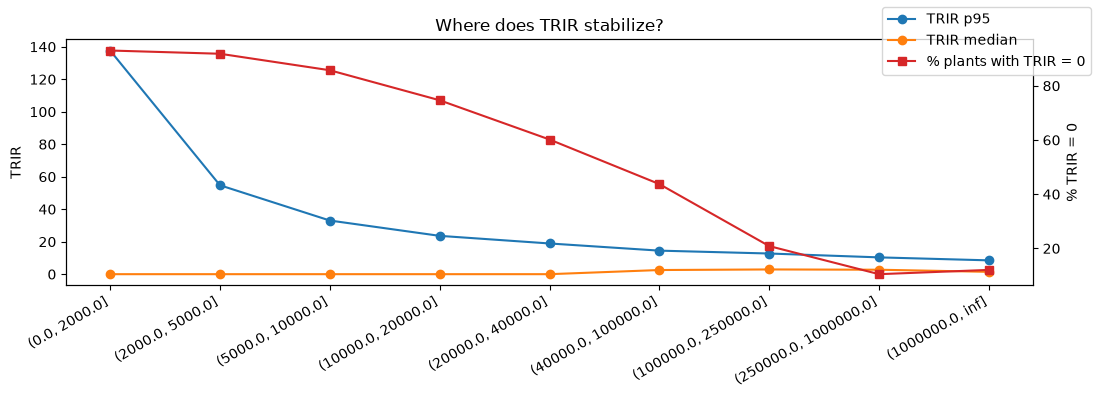

In [6]:
fig, ax1 = plt.subplots(figsize=(11, 4))
labels = [str(b) for b in by_size.index]
ax1.plot(labels, by_size['p95'], marker='o', label='TRIR p95')
ax1.plot(labels, by_size['median'], marker='o', label='TRIR median')
ax1.set_ylabel('TRIR')
ax2 = ax1.twinx()
ax2.plot(labels, by_size['share_zero'], marker='s', color='tab:red', label='% plants with TRIR = 0')
ax2.set_ylabel('% TRIR = 0')
ax1.set_xticks(range(len(labels)))
ax1.set_xticklabels(labels, rotation=30, ha='right')
ax1.set_title('Where does TRIR stabilize?')
fig.legend(loc='upper right')
plt.tight_layout()
plt.show()

### 1.4 Sensitivity: what each threshold costs

Raising the threshold makes rates more reliable, but drops plants and shrinks cohorts.

In [7]:
def cohort_coverage(frame, min_cohort):
    sizes = frame['naics_6'].value_counts()
    ok = sizes >= min_cohort
    return int(ok.sum()), sizes[ok].sum() / len(frame) * 100

rows = []
for threshold in [0, 2_000, 5_000, 10_000, 20_000, 40_000]:
    kept = computable[computable['total_hours_worked'] >= threshold]
    cohorts_ok, covered = cohort_coverage(kept, CONFIG['min_cohort'])
    rows.append({
        'min_hours': threshold,
        'plants kept': len(kept),
        '% dropped': (1 - len(kept) / len(computable)) * 100,
        '% TRIR = 0': (kept['trir'] == 0).mean() * 100,
        'TRIR p95': kept['trir'].quantile(.95),
        f'6-digit cohorts >= {CONFIG["min_cohort"]}': cohorts_ok,
        '% plants in those cohorts': covered,
    })
pd.DataFrame(rows).set_index('min_hours')

,plants kept,% dropped,% TRIR = 0,TRIR p95,6-digit cohorts >= 30,% plants in those cohorts
min_hours,,,,,,
0,378649,0.00,43.88,16.23,791,99.08
2000,367752,2.88,42.44,16.11,788,99.04
5000,350137,7.53,39.94,15.91,781,98.96
10000,331004,12.58,37.29,15.14,772,98.89
20000,297031,21.56,33.02,14.01,746,98.68
40000,246000,35.03,27.38,12.86,709,98.39


## 2. Hours per employee bounds D-004

A full-time employee works ~2,000 h/year. More than 8,760 h (24 × 365) is impossible. DEFINE THIS

In [8]:
hpe = computable['hours_per_employee']
print(hpe.describe(percentiles=[.001, .01, .05, .5, .95, .99, .999]).to_string(), end='\n\n')

for low in [100, 250, 500, 1_000]:
    print(f'hours/employee < {low:>5,}: {(hpe < low).sum():>7,}')
for high in [4_000, 5_000, 8_760]:
    print(f'hours/employee > {high:>5,}: {(hpe > high).sum():>7,}')

count         378,649.00
mean           37,263.28
std         7,585,499.12
min                 0.00
0.1%                4.00
1%                163.39
5%                667.37
50%             1,794.13
95%             2,482.90
99%             3,715.49
99.9%         181,783.78
max     2,171,072,857.14

hours/employee <   100:   2,456
hours/employee <   250:   5,769
hours/employee <   500:  12,104
hours/employee < 1,000:  37,104
hours/employee > 4,000:   3,352
hours/employee > 5,000:   2,624
hours/employee > 8,760:   1,996


In [ ]:
low_hpe = computable[hpe < 500]
(low_hpe['industry_description'].value_counts().head(15)
 .to_frame('plants with < 500 h/employee'))

,plants with < 500 h/employee
industry_description,
Food Service Contractors,1697
Skilled nursing facilities,152
Staffing,131
Hotels (except casino hotels),120
"Fire departments (e.g., government, volunteer (except private))",108
Couriers and Express Delivery Services,106
Assisted-living facilities without on-site nursing care facilities,103
Janitorial services,103
General Line Grocery Merchant Wholesalers,97


In [10]:
COLUMNS = ['establishment_name', 'industry_description', 'annual_average_employees', 'total_hours_worked', 'hours_per_employee', 'recordable_cases', 'trir']
print('Lowest hours per employee')
display(computable.nsmallest(10, 'hours_per_employee')[COLUMNS])
print('Highest hours per employee')
display(computable.nlargest(10, 'hours_per_employee')[COLUMNS])

Lowest hours per employee


,establishment_name,industry_description,annual_average_employees,total_hours_worked,hours_per_employee,recordable_cases,trir
1321,On Top Of The World Communities LLC,Real property (except cemeteries) subdivision,120667434,727,0.00,10,"2,751.03"
212710,CH Services,School bus services,8527485,78,0.00,0,0.00
277053,"Genesis Marine,LLC",Marine Shipping,2650440,552,0.00,5,"1,811.59"
136835,Workplace Health- Candlers,Physicians' (except mental health) offices (e....,21612,7,0.00,0,0.00
92837,Brookdale Roseburg,Assisted-living facilities without on-site nur...,94966,34,0.00,8,"47,058.82"
321461,"Cadence, LLC",Commercial building construction general contr...,66896,24,0.00,0,0.00
274414,Brookdale Mandeville,Assisted-living facilities without on-site nur...,79350,31,0.00,0,0.00
96225,Brookdale Senior Living Walla WallaSenior,Assisted-living facilities without on-site nur...,61452,26,0.00,1,"7,692.31"
121803,Metrie EL & EL - Galt,"Moldings, clear and finger joint wood, manufac...",295199,126,0.00,3,"4,761.90"
104979,Olin Corporation - Niagara Falls Operations,"Chlorine compounds, not specified elsewhere by...",399719,174,0.00,0,0.00


Highest hours per employee


,establishment_name,industry_description,annual_average_employees,total_hours_worked,hours_per_employee,recordable_cases,trir
86094,Vespyr Brands,"Pharmaceutical preparations (e.g., capsules, l...",7,15197510000,"2,171,072,857.14",0,0.00
95459,Acrotech Biopharma,"Pharmaceutical preparations (e.g., capsules, l...",60,119759000000,"1,995,983,333.33",0,0.00
95460,Auro Vaccines,"Pharmaceutical preparations (e.g., capsules, l...",10,19264000000,"1,926,400,000.00",0,0.00
101541,203A- AuroLogistics LLC,Logistics management consulting services,8,15135083300,"1,891,885,412.50",1,0.00
95457,Aurohealth,"Pharmaceutical preparations (e.g., capsules, l...",22,40036210000,"1,819,827,727.27",0,0.00
95456,Aurolife Pharma,"Pharmaceutical preparations (e.g., capsules, l...",137,140142000000,"1,022,934,306.57",1,0.00
95395,Auropackaging,Blister packaging services,44,41577660000,"944,946,818.18",0,0.00
95458,Aurologistics,General warehousing and storage,147,100551000000,"684,020,408.16",5,0.00
95717,Aurologistics LLC,"Pharmaceutical preparations (e.g., capsules, l...",6,1620000000,"270,000,000.00",0,0.00
137315,Regal - Home CA,Wineries,183,3885479300,"21,232,127.32",1,0.00


**For D-004, answer:** is the upper bound the physical limit (8,760) or something tighter? Is there a lower bound, or are low values real (seasonal, part-time) and the min-hours rule from D-003 already covers the noise?

## 3. Percentile definition and ties at zero → D-005

| Definition | Formula | PostgreSQL equivalent |
|---|---|---|
| Strict | % below x | similar to percent_rank() |
| Weak | % below + % tied | cume_dist() |
| Mid-rank | % below + ½ · % tied | none (compute by hand) |

In [11]:
base = computable[computable['total_hours_worked'] >= CONFIG['min_hours']]

def position(values, x):
    values = np.asarray(values, dtype=float)
    below = (values < x).mean() * 100
    tied = (values == x).mean() * 100
    return {
        '% below': below, '% tied': tied, '% above': 100 - below - tied,
        'strict': below, 'weak': below + tied, 'mid-rank': below + tied / 2,
    }

stats = base.groupby('naics_6')['trir'].agg(plants='size', share_zero=lambda s: (s == 0).mean(), median='median')
eligible = stats[stats['plants'] >= 100]
examples = {
    'zero-heavy cohort': eligible['share_zero'].idxmax(),
    'typical cohort': (eligible['share_zero'] - eligible['share_zero'].median()).abs().idxmin(),
    'few-zeros cohort': eligible['share_zero'].idxmin(),
}

rows = []
for kind, naics in examples.items():
    cohort = base.loc[base['naics_6'] == naics, 'trir']
    label = base.loc[base['naics_6'] == naics, 'industry_description'].mode().iat[0]
    for name, x in [('TRIR 0', 0.0), ('cohort median', cohort.median()), ('cohort p90', cohort.quantile(.90))]:
        rows.append({'cohort': f'{kind}: {naics} {label}', 'plants': len(cohort), 'user TRIR': f'{name} = {x:.2f}', **position(cohort, x)})

pd.DataFrame(rows).set_index(['cohort', 'plants', 'user TRIR'])

% below  \
cohort                                             plants user TRIR                       
zero-heavy cohort: 561499 Other Business Suppor... 118    TRIR 0 = 0.00            0.00   
                                                          cohort median = 0.00     0.00   
                                                          cohort p90 = 1.75       89.83   
typical cohort: 621493 Ambulatory surgical cent... 388    TRIR 0 = 0.00            0.00   
                                                          cohort median = 2.83    50.00   
                                                          cohort p90 = 14.32      89.95   
few-zeros cohort: 455211 Warehouse Clubs and Su... 6269   TRIR 0 = 0.00            0.00   
                                                          cohort median = 4.93    49.99   
                                                          cohort p90 = 8.91       90.00   

                                                                                % tied  \
cohort                                             plants user TRIR                      
zero-heavy cohort: 561499 Other Business Suppor... 118    TRIR 0 = 0.00          87.29   
                                                          cohort median = 0.00   87.29   
                                                          cohort p90 = 1.75       0.00   
typical cohort: 621493 Ambulatory surgical cent... 388    TRIR 0 = 0.00          38.66   
                                                          cohort median = 2.83    0.00   
                                                          cohort p90 = 14.32      0.00   
few-zeros cohort: 455211 Warehouse Clubs and Su... 6269   TRIR 0 = 0.00           1.20   
                                                          cohort median = 4.93    0.02   
                                                          cohort p90 = 8.91       0.00   

                                                                                % above  \
cohort                                             plants user TRIR                       
zero-heavy cohort: 561499 Other Business Suppor... 118    TRIR 0 = 0.00           12.71   
                                                          cohort median = 0.00    12.71   
                                                          cohort p90 = 1.75       10.17   
typical cohort: 621493 Ambulatory surgical cent... 388    TRIR 0 = 0.00           61.34   
                                                          cohort median = 2.83    50.00   
                                                          cohort p90 = 14.32      10.05   
few-zeros cohort: 455211 Warehouse Clubs and Su... 6269   TRIR 0 = 0.00           98.80   
                                                          cohort median = 4.93    49.99   
                                                          cohort p90 = 8.91       10.00   

                                                                                strict  \
cohort                                             plants user TRIR                      
zero-heavy cohort: 561499 Other Business Suppor... 118    TRIR 0 = 0.00           0.00   
                                                          cohort median = 0.00    0.00   
                                                          cohort p90 = 1.75      89.83   
typical cohort: 621493 Ambulatory surgical cent... 388    TRIR 0 = 0.00           0.00   
                                                          cohort median = 2.83   50.00   
                                                          cohort p90 = 14.32     89.95   
few-zeros cohort: 455211 Warehouse Clubs and Su... 6269   TRIR 0 = 0.00           0.00   
                                                          cohort median = 4.93   49.99   
                                                          cohort p90 = 8.91      90.00   

                                                                                weak  \
cohort

In [12]:
print(f"Cohorts (>= 100 plants) where the median plant has TRIR = 0: {(eligible['median'] == 0).sum()} of {len(eligible)}")
print(f"Largest 6-digit cohort: {stats['plants'].max():,} plants")

Cohorts (>= 100 plants) where the median plant has TRIR = 0: 130 of 492
Largest 6-digit cohort: 18,253 plants


**For D-005, answer:**
1. Which definition? And how does the verdict read for a user who ties with a big group (e.g. *"You're tied with 62% of plants at zero recordable cases"* rather than a single misleading percentile)?
2. **Architecture impact:** `cohort_stats` as designed stores only p25/median/p75 plus histogram buckets. That's **not enough** to compute an exact rank for an arbitrary user TRIR. Options:
   - store the cohort's sorted TRIR values, or p1…p99, in JSONB (check the largest cohort size above)
   - count at request time: `COUNT(*) FILTER (WHERE trir < x)` over an index on `(naics_code, year, trir)`
   - approximate from the histogram buckets (least accurate right where users care)

   Whichever you pick, store `share_zero` so the verdict can mention ties.

## 4. NAICS code versions → D-006

Plants report NAICS codes from the **2012, 2017 or 2022** editions. When an industry got a new code in a later edition, the same industry ends up split across two cohorts, and each one benchmarks against only part of its real peers.

The 2022 edition restructured **retail trade (sectors 44–45)** almost completely, so it's the clearest place to measure the problem.

In [13]:
df['naics_year'].value_counts(dropna=False).sort_index().to_frame('rows')

,rows
naics_year,
0,167
2012,139490
2017,12143
2022,231474
2025,3


In [14]:
# Retail 3-digit codes that exist ONLY before 2022 vs ONLY in the 2022 edition
RETAIL_PRE_2022 = ['442', '443', '446', '447', '448', '451', '452', '453', '454']
RETAIL_2022 = ['449', '455', '456', '457', '458', '459']

retail = df[df['naics_2'].isin(['44', '45'])]
pd.crosstab(retail['naics_3'], retail['naics_year'], margins=True)

naics_year,2012,2017,2022,All
naics_3,,,,
441,2689,1106,2656,6451
442,864,685,2,1551
443,20,21,0,41
444,3162,3343,3726,10231
445,10603,1526,8949,21078
446,81,314,8,403
447,383,409,0,792
448,74,114,1,189
449,35,28,442,505


In [15]:
retail_generation = np.select(
    [retail['naics_3'].isin(RETAIL_PRE_2022), retail['naics_3'].isin(RETAIL_2022)],
    ['pre-2022 code', '2022-only code'],
    default='code unchanged',
)
generation = pd.crosstab(pd.Series(retail_generation, index=retail.index, name='code generation'), retail['naics_year'])
display(generation)

mislabeled = (retail_generation == '2022-only code') & (retail['naics_year'] != 2022)
print(f'Rows with a 2022-only code but naics_year != 2022: {mislabeled.sum():,}  →  naics_year cannot be trusted to identify the edition')

naics_year,2012,2017,2022
code generation,,,
2022-only code,6222,170,4296
code unchanged,16454,5975,15331
pre-2022 code,6754,4505,43


Rows with a 2022-only code but naics_year != 2022: 6,392  →  naics_year cannot be trusted to identify the edition


In [16]:
# Concrete example: general merchandise stores. 452 (pre-2022) became 455 (2022)
gm = df[df['naics_3'].isin(['452', '455'])]
(gm.groupby(['naics_6', 'naics_3'])
   .agg(plants=('id', 'size'), description=('industry_description', lambda s: s.mode().iat[0] if s.notna().any() else ''))
   .sort_values('plants', ascending=False))

,,plants,description
naics_6,naics_3,,
455211,455,6270,Warehouse Clubs and Supercenters
452112,452,2973,Discount Department Stores
452210,452,1769,Department Stores
455110,455,489,Discount Department Stores
452111,452,365,Department stores except discount department s...
455219,455,238,All Other General Merchandise Retailers
452990,452,116,Retail
452319,452,47,"Trading posts, general merchandise"
452910,452,13,"Warehouse clubs (i.e., food and general mercha..."


In [17]:
retail_pre = retail['naics_3'].isin(RETAIL_PRE_2022)
print(f'Retail rows still on pre-2022 codes: {retail_pre.sum():,} of {len(retail):,} ({retail_pre.mean():.0%})')

Retail rows still on pre-2022 codes: 11,302 of 59,750 (19%)


**Retail is only the most visible case.** Other sectors also changed codes in 2017 and 2022. A complete fix requires the official Census concordance tables (2012→2017 and 2017→2022), available under *Concordances* at [census.gov/naics](https://www.census.gov/naics/).

**For D-006, answer:**
- **A.** Map every code to 2022 NAICS with the Census concordances during ingestion. Most correct, and more work. Codes that split one-to-many need a rule.
- **B.** Map only the sectors that changed a lot (retail), document the rest as a limitation.
- **C.** Keep codes as reported and document the limitation. Easiest, but split cohorts give wrong benchmarks for retail users.

Also: which edition does the **form** show the user? The `naics_reference` catalog has to match the codes stored in `establishment_summary`.

## 5. Government establishments → D-007

`establishment_type`: 1 = private, 2 = state government, 3 = local government.

In [18]:
TYPE_LABELS = {1: 'private', 2: 'state gov', 3: 'local gov'}
df['owner'] = df['establishment_type'].map(TYPE_LABELS).fillna('missing/invalid')
base = base.assign(owner=base['establishment_type'].map(TYPE_LABELS).fillna('missing/invalid'))

df['owner'].value_counts().to_frame('rows')

,rows
owner,
private,355344
state gov,16183
local gov,11313
missing/invalid,437


In [19]:
# Sectors where government plants are a large share
gov_share = (base.assign(is_gov=base['owner'].isin(['state gov', 'local gov']))
             .groupby('naics_2')['is_gov'].agg(plants='size', pct_gov=lambda s: s.mean() * 100)
             .sort_values('pct_gov', ascending=False))
gov_share.head(12)

,plants,pct_gov
naics_2,,
95,1,100.00
92,6599,97.01
61,2732,82.21
49,23337,37.85
99,5,20.00
22,6304,15.56
71,3326,11.76
54,3902,5.33
51,2310,4.68


In [20]:
# Same 6-digit industry, different owner: do their TRIR distributions differ?
mixed = base.groupby('naics_6')['owner'].agg(lambda s: s.isin(['state gov', 'local gov']).mean())
mixed_codes = mixed[(mixed > 0.1) & (mixed < 0.9)].index
comparison = (base[base['naics_6'].isin(mixed_codes) & base['owner'].ne('missing/invalid')]
              .groupby(['naics_6', 'owner'])['trir']
              .agg(plants='size', median='median', p75=lambda s: s.quantile(.75), share_zero=lambda s: (s == 0).mean() * 100))
comparison = comparison[comparison['plants'] >= 30]
comparison.head(30)

plants  median   p75  share_zero
naics_6 owner                                      
112511  private        33    3.71  8.94       48.48
115310  private        66    1.72  5.29       40.91
221111  private       109    0.00  3.65       54.13
221118  private        47    0.00  1.41       63.83
221310  local gov     365    3.46  7.50       35.07
        private       358    0.00  2.90       64.25
        state gov      81    0.00  5.77       55.56
221320  local gov     248    2.67  6.56       37.10
        private       170    0.00  3.90       57.06
237310  local gov     271    6.50 13.16       21.03
        private      2376    1.69  3.94       34.76
        state gov     550    0.00  0.13       59.09
337127  private       107    3.43  5.99       23.36
445310  private        61    0.00  2.75       68.85
485111  local gov     158    4.96  7.96       19.62
        private       190    4.46  9.12       17.37
485113  local gov      55    4.11  7.62       23.64
        private        81    5.18  7.40       16.05
485210  private        37    2.25  6.06       45.95
488310  private        32    2.53  6.51       31.25
488490  private       398    0.00  5.21       53.52
524114  private        61    0.00  0.35       50.82
541511  private        88    0.00  0.00       76.14
541712  private       153    0.00  0.43       62.09
        state gov      97    0.00  0.00       75.26
561920  private        45    2.66  5.23       31.11
562212  local gov      61    6.76 12.16       26.23
        private       247    1.54  4.65       47.77
611110  local gov    1080    3.42  6.52       22.22
        private       219    3.78  9.94       22.83

**For D-007, answer:**
- **A.** Include all owners in the same cohort
- **B.** Exclude government plants (the product targets private-sector EHS managers)
- **C.** Keep them but let the user choose, or cohort by owner type (more complex; beyond the MVP cut line?)

Also decide what to do with the rows where `establishment_type` is missing or invalid.

## 6. Other inconsistent rows → D-008

For each flag, decide: **drop**, **keep**, or **keep and flag**.

In [21]:
flags = {
    'naics_year not in (2012, 2017, 2022)': ~df['naics_year'].isin([2012, 2017, 2022]),
    'recordable cases > average employees': df['recordable_cases'] > df['annual_average_employees'],
    'DAFW days > 0 but DAFW cases = 0': (df['total_dafw_days'] > 0) & (df['total_dafw_cases'] == 0),
    'DAFW cases > 0 but DAFW days = 0': (df['total_dafw_cases'] > 0) & (df['total_dafw_days'] == 0),
    'no_injuries_illnesses = 1 but 0 cases': (df['no_injuries_illnesses'] == 1) & (df['recordable_cases'] == 0),
    'legacy size code 2 (20-249)': df['size'] == 2,
}
flags = {name: mask.fillna(False).astype(bool) for name, mask in flags.items()}
pd.DataFrame({
    'rows': {n: m.sum() for n, m in flags.items()},
    '% rows': {n: m.mean() * 100 for n, m in flags.items()},
})

,rows,% rows
"naics_year not in (2012, 2017, 2022)",170,0.04
recordable cases > average employees,412,0.11
DAFW days > 0 but DAFW cases = 0,229,0.06
DAFW cases > 0 but DAFW days = 0,258,0.07
no_injuries_illnesses = 1 but 0 cases,8,0.00
legacy size code 2 (20-249),33123,8.64


In [22]:
print("naics_year not in (2012, 2017, 2022): example rows")
display(df.loc[flags['naics_year not in (2012, 2017, 2022)'], ['establishment_name', 'naics_code', 'naics_year', 'industry_description']].head(8))

print('Cases > employees: which industries? (high turnover, e.g. staffing, could make this legitimate)')
display(df.loc[flags['recordable cases > average employees'], 'industry_description'].value_counts().head(10).to_frame('rows'))

naics_year not in (2012, 2017, 2022): example rows


,establishment_name,naics_code,naics_year,industry_description
19813,493006-East Providence | RI | OST-100,485410,0,485410
19824,293001-Hopkinton (Region Admin) | MA | SMA-000,485410,0,485410
30334,143022-Pasadena | CA | 143022,485410,0,485410
30359,403014-Londonderry | NH | LON-000,485410,0,485410
30360,403013-Windham / Pelham | NH | GOF-400,485410,0,485410
30361,403010-Rochester | NH | 403010,485410,0,485410
30362,313010-Kezar Falls | ME | SME-500,485410,0,485410
30363,313006-York | ME | SME-100,485410,0,485410


Cases > employees: which industries? (high turnover, e.g. staffing, could make this legitimate)


,rows
industry_description,
Golf Courses and Country Clubs,86
Mail and Parcel Delivery,44
Hardware Retailers,40
Service to Buildings and Dwellings,19
Tire and Tube Merchant Wholesalers,7
"Activity centers for disabled persons, the elderly, and persons diagnosed with intellectual and developmental disabilities",6
Lessors - Residential Bldgs & Dwellings,5
Healthcare,4
Other Building Material Dealers,4


**For D-008, notes:**
- `size` isn't used in the benchmark, so legacy code 2 probably needs no action.
- The DAFW days/cases mismatches don't affect TRIR. They only matter if you ever report DART severity.

## 7. Full pipeline with the current CONFIG → D-009

Applies every rule **in order** and assigns each dropped row to the **first** rule it fails, the same way `load_ita` will log it.
This is a preview of the quality report the ingestion command should print.

In [23]:
RULES = [
    ('hours worked <= 0', df['total_hours_worked'] <= 0),
    ('average employees <= 0', df['annual_average_employees'] <= 0),
    ('invalid NAICS code', df['naics_6'].isna()),
    ('naics_year not 2012/2017/2022', ~df['naics_year'].isin([2012, 2017, 2022]) if CONFIG['drop_invalid_naics_year'] else pd.Series(False, index=df.index)),
    (f"hours worked < {CONFIG['min_hours']:,}", df['total_hours_worked'] < CONFIG['min_hours']),
    (f"hours/employee > {CONFIG['max_hours_per_employee']:,}", df['hours_per_employee'] > CONFIG['max_hours_per_employee']),
    (f"hours/employee < {CONFIG['min_hours_per_employee']:,}", df['hours_per_employee'] < CONFIG['min_hours_per_employee']),
    ('cases > average employees', (df['recordable_cases'] > df['annual_average_employees']) if CONFIG['drop_cases_gt_employees'] else pd.Series(False, index=df.index)),
    ('government establishment', df['establishment_type'].isin([2, 3]) if not CONFIG['include_government'] else pd.Series(False, index=df.index)),
]

drop_reason = pd.Series(pd.NA, index=df.index, dtype='string')
for name, mask in RULES:
    mask = pd.Series(mask, index=df.index).fillna(False).astype(bool)
    drop_reason = drop_reason.mask(drop_reason.isna() & mask, name)

report = drop_reason.value_counts().reindex([name for name, _ in RULES]).fillna(0).astype(int).to_frame('rows dropped')
report['% of loaded rows'] = report['rows dropped'] / len(df) * 100
report.loc['TOTAL DROPPED'] = [report['rows dropped'].sum(), report['rows dropped'].sum() / len(df) * 100]

clean = df[drop_reason.isna()].copy()
print(f"Raw rows:        {len(raw) + len(malformed):,}")
print(f"Malformed:       {len(malformed):,}")
print(f"Loaded:          {len(df):,}")
print(f"Accepted:        {len(clean):,} ({len(clean) / len(df):.1%})")
report

Raw rows:        383,283
Malformed:       6
Loaded:          383,277
Accepted:        327,441 (85.4%)


,rows dropped,% of loaded rows
hours worked <= 0,"1,834.00",0.48
average employees <= 0,"2,794.00",0.73
invalid NAICS code,0.00,0.00
naics_year not 2012/2017/2022,170.00,0.04
"hours worked < 10,000","47,639.00",12.43
"hours/employee > 8,760","1,988.00",0.52
hours/employee < 250,"1,384.00",0.36
cases > average employees,27.00,0.01
government establishment,0.00,0.00
TOTAL DROPPED,"55,836.00",14.57


### 7.1 Minimum cohort size and the fallback

In [24]:
def fallback_levels(frame, min_cohort):
    size_6 = frame['naics_6'].map(frame['naics_6'].value_counts())
    size_4 = frame['naics_4'].map(frame['naics_4'].value_counts())
    return pd.Series(np.select([size_6 >= min_cohort, size_4 >= min_cohort], ['6-digit', '4-digit'], 'no percentile'), index=frame.index)

rows = []
for min_cohort in [10, 20, 30, 50, 100]:
    levels = fallback_levels(clean, min_cohort).value_counts(normalize=True) * 100
    rows.append({'min_cohort': min_cohort, **levels.reindex(['6-digit', '4-digit', 'no percentile']).fillna(0).to_dict()})
pd.DataFrame(rows).set_index('min_cohort').rename(columns=lambda c: f'% plants benchmarked at {c}')

,% plants benchmarked at 6-digit,% plants benchmarked at 4-digit,% plants benchmarked at no percentile
min_cohort,,,
10,99.74,0.22,0.04
20,99.37,0.54,0.10
30,98.88,0.92,0.20
50,97.70,1.89,0.41
100,93.77,5.02,1.22


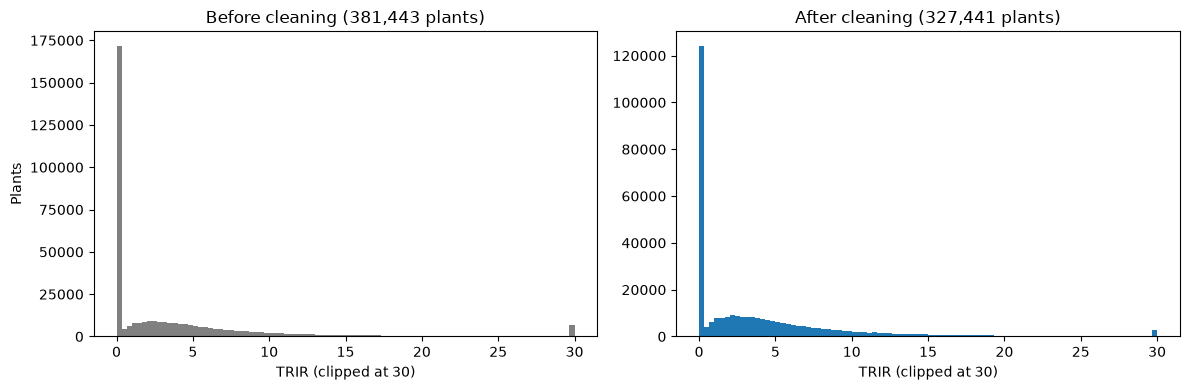

,before,after
count,"381,443.00","327,441.00"
mean,76.27,4.09
std,"19,268.46",6.26
min,0.00,0.00
25%,0.00,0.00
50%,1.35,2.18
75%,5.34,5.80
95%,16.17,15.00
99%,41.15,27.59
max,"7,200,000.00",403.65


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
axes[0].hist(df['trir'].dropna().clip(upper=30), bins=90, color='grey')
axes[0].set_title(f'Before cleaning ({df["trir"].notna().sum():,} plants)')
axes[1].hist(clean['trir'].clip(upper=30), bins=90)
axes[1].set_title(f'After cleaning ({len(clean):,} plants)')
for ax in axes:
    ax.set_xlabel('TRIR (clipped at 30)')
axes[0].set_ylabel('Plants')
plt.tight_layout()
plt.show()

pd.DataFrame({
    'before': df['trir'].describe(percentiles=[.25, .5, .75, .95, .99]),
    'after': clean['trir'].describe(percentiles=[.25, .5, .75, .95, .99]),
})

**For D-009, answer:** what minimum cohort size gives a percentile you'd defend in front of an EHS manager? Keep in mind that D-003 and D-006 change the cohort sizes, so revisit this after deciding them.

---

## Next

1. Record each decision in `docs/decisions.md` with the numbers from this notebook.
2. Set `CONFIG` to the final values and use **Run All**. Section 7 is the expected ingestion report.
3. Update `architecture.md`: unique key, percentile storage (D-005), NAICS normalization (D-006), and the new columns the model needs.